# Phase 2.x — Covering-array strain screening + tree-model analysis

**The campaign.** We have **50 candidate strains** and a budget of **200 experiments**. Each
experiment ferments milk with a **combination of 2–5 strains**, and the lab records the pH
curve. The questions:

1. *Which combinations should we run?* — testing all combinations is impossible, but to learn
   pairwise strain effects it is enough that **every pair of strains is co-tested at least
   once**. That is a (strength-2) **covering array** with a 2–5-strain block-size constraint.
2. *Which strains actually drive the outcome?* — the response is noisy and interaction-heavy, so
   we screen it with **Random Forest** and **XGBoost** and read off permutation importance.

Because this is a *virtual* lab we know the ground truth (each strain's intrinsic acidifying
power), so we can check whether the design + analysis actually recover the influential strains
from only 200 noisy runs.

In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from downstream_doe.config import make_rng
from downstream_doe.models import fermentation as ferm
from downstream_doe.doe.covering import covering_array
from downstream_doe.doe.importance import random_forest_importance, gradient_boosting_importance

N_STRAINS, N_RUNS = 50, 200
T_GRID = np.linspace(0, 12, 241)        # hours
rng = make_rng(2026)

## 1 — A library of 50 candidate strains

Each strain gets realistic but randomized kinetics (growth rate, temperature optimum, acid
tolerance, acidifying power, lag), spanning strong fast acidifiers to weak slow ones. A sparse
set of **cooperative** and **antagonistic** strain pairs is planted as hidden ground truth.

In [2]:
library = ferm.random_strain_library(N_STRAINS, rng)
params = pd.DataFrame({
    'mu_max': [s.mu_max for s in library.strains],
    't_opt': [s.t_opt for s in library.strains],
    'ph_min': [s.ph_min for s in library.strains],
    'acid_growth': [s.acid_growth for s in library.strains],
}, index=library.names)
print(params.describe().round(2).loc[['min', 'mean', 'max']])
print('\nplanted interaction pairs:',
      int((np.triu(library.interaction) > 0).sum()), 'cooperative,',
      int((np.triu(library.interaction) < 0).sum()), 'antagonistic')

      mu_max  t_opt  ph_min  acid_growth
min     0.61  39.30    3.71        80.84
mean    1.05  42.74    4.28       110.04
max     1.49  45.96    4.90       144.14

planted interaction pairs: 10 cooperative, 5 antagonistic


### Ground truth: each strain's intrinsic acidifying power

We simulate every strain **alone** at the screening temperature and record the final pH it can
reach. Low solo-pH = strong acidifier. This is the benchmark the screen should rediscover —
but the screen only ever sees 2–5-strain mixtures, never single strains.

In [3]:
solo_ph = np.array([
    ferm.run_fermentation(
        ferm.FermentationSetup(consortium=library.consortium([i]), temperature=43.0), T_GRID
    ).ph[-1]
    for i in range(N_STRAINS)
])
solo = pd.Series(solo_ph, index=library.names).sort_values()
print('strongest solo acidifiers (lowest final pH):')
print(solo.head(8).round(3))

strongest solo acidifiers (lowest final pH):
strain_13    4.292
strain_09    4.292
strain_45    4.361
strain_12    4.373
strain_39    4.375
strain_33    4.395
strain_10    4.457
strain_05    4.471
dtype: float64


## 2 — The covering-array design

200 runs, each activating 2–5 strains, built greedily to co-test as many of the 1225 strain
pairs as possible while keeping each strain's usage balanced.

pairs co-tested: 1124 / 1225 (91.8%)
strain appearances: min 14, mean 15.4, max 19


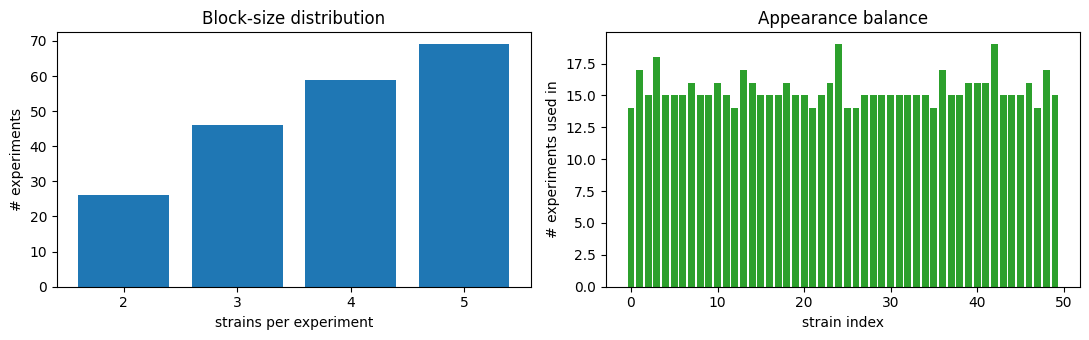

In [4]:
design = covering_array(N_STRAINS, N_RUNS, min_size=2, max_size=5, strength=2, seed=11)
cov = design.coverage(2)
print(f"pairs co-tested: {cov['subsets_covered']} / {cov['subsets_total']} "
      f"({cov['coverage_fraction']:.1%})")
print(f"strain appearances: min {cov['appearances_min']}, "
      f"mean {cov['appearances_mean']:.1f}, max {cov['appearances_max']}")

sizes = np.array([len(r) for r in design.runs])
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.5))
ax1.hist(sizes, bins=np.arange(1.5, 6.5), rwidth=0.8, color='tab:blue')
ax1.set(xlabel='strains per experiment', ylabel='# experiments', title='Block-size distribution')
ax1.set_xticks([2, 3, 4, 5])
ax2.bar(range(N_STRAINS), design.appearances(), color='tab:green')
ax2.set(xlabel='strain index', ylabel='# experiments used in', title='Appearance balance')
plt.tight_layout()

## 3 — Run the 200 virtual experiments

Each run is **one real batch**: it carries biological batch-to-batch variability *and* pH-probe
measurement noise (the model's variability + uncertainty layers). We extract two responses:

- **final pH** — always defined,
- **time to set point** (pH 4.6) — censored at the 12 h horizon when a combination never sets.

In [5]:
var = ferm.BatchVariability()
final_ph, t_set, did_set = [], [], []
for members in design.runs:
    setup = ferm.FermentationSetup(consortium=library.consortium(members), temperature=43.0)
    batch = ferm.sample_batch(setup, var, rng)          # biological variability
    r = ferm.run_fermentation(batch, T_GRID, rng=rng)
    obs = ferm.observe_ph(r, T_GRID, rng=rng)            # pH-probe measurement noise
    final_ph.append(float(obs['ph'][-1]))
    ts = ferm.time_to_ph(obs['t'], obs['ph'], 4.6)
    did_set.append(np.isfinite(ts))
    t_set.append(float(ts) if np.isfinite(ts) else float(T_GRID[-1]))   # censored

final_ph = np.array(final_ph); t_set = np.array(t_set)
X = design.matrix()                                      # 200 x 50 presence matrix
print(f"final pH: {final_ph.min():.2f} – {final_ph.max():.2f};  "
      f"{int(np.sum(did_set))}/{N_RUNS} combinations reached the set point")

final pH: 4.25 – 4.99;  131/200 combinations reached the set point


## 4 — Random Forest vs XGBoost

We regress each response on the 50-column strain-presence matrix and compare cross-validated
R² (out-of-sample explanatory power) and predicted-vs-actual fit.

final pH        RF CV R2 = 0.562   XGB CV R2 = 0.557


set time (h)    RF CV R2 = 0.588   XGB CV R2 = 0.619


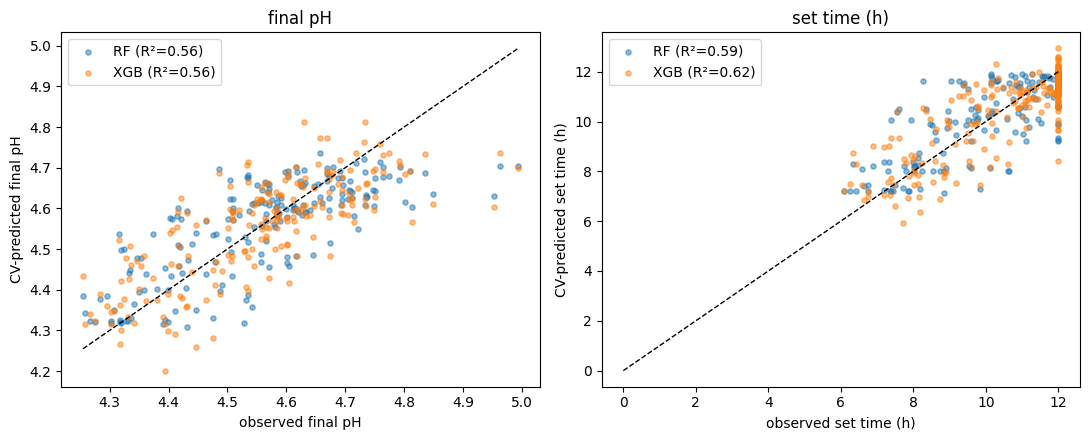

In [6]:
names = library.names
results = {}
for resp_name, y in [('final pH', final_ph), ('set time (h)', t_set)]:
    rf = random_forest_importance(X, y, feature_names=names, seed=1, n_repeats=8)
    xgb = gradient_boosting_importance(X, y, feature_names=names, seed=1, n_repeats=8)
    results[resp_name] = {'RF': rf, 'XGB': xgb}
    print(f"{resp_name:14s}  RF CV R2 = {rf.cv_score:.3f}   XGB CV R2 = {xgb.cv_score:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (resp_name, y) in zip(axes, [('final pH', final_ph), ('set time (h)', t_set)]):
    for mdl, c in [('RF', 'tab:blue'), ('XGB', 'tab:orange')]:
        res = results[resp_name][mdl]
        ax.scatter(y, res.predictions, s=14, alpha=0.5, color=c,
                   label=f"{mdl} (R²={res.cv_score:.2f})")
    lims = [min(y.min(), 0) if 'time' in resp_name else y.min(), y.max()]
    ax.plot(lims, lims, 'k--', lw=1)
    ax.set(xlabel=f'observed {resp_name}', ylabel=f'CV-predicted {resp_name}',
           title=resp_name); ax.legend()
plt.tight_layout()

## 5 — Which strains drive the result?

Permutation importance on the **final pH** model. We overlay each strain's true solo-acidifying
power: the strains the screen flags as most important should be the genuinely strong (or
strongly interacting) acidifiers — recovered from mixtures alone.

RF top-10 ∩ true 10 strongest acidifiers: 8 / 10
rank correlation (importance vs −solo pH): 0.45


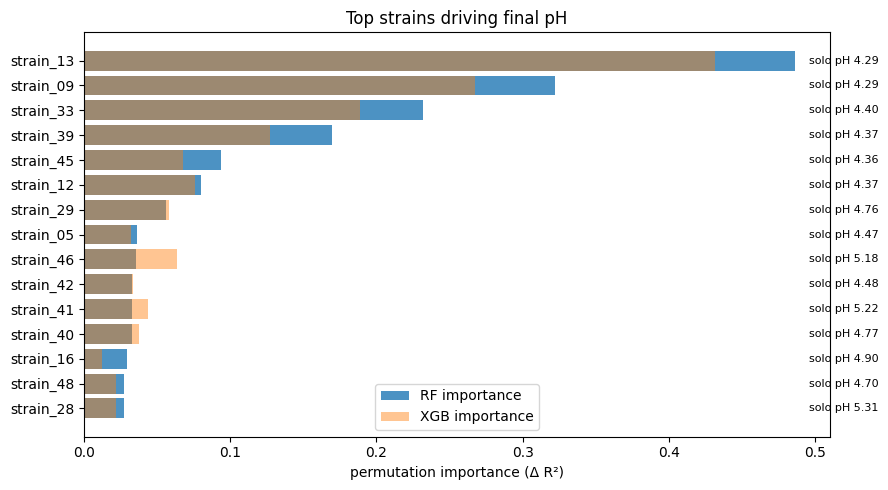

In [7]:
rf = results['final pH']['RF']
xgb = results['final pH']['XGB']
top = rf.importances.head(15)

fig, ax = plt.subplots(figsize=(9, 5))
ypos = np.arange(len(top))[::-1]
ax.barh(ypos, top.values, color='tab:blue', alpha=0.8, label='RF importance')
ax.barh(ypos, xgb.importances[top.index].values, color='tab:orange', alpha=0.45,
        label='XGB importance')
ax.set_yticks(ypos); ax.set_yticklabels(top.index)
ax.set(xlabel='permutation importance (Δ R²)', title='Top strains driving final pH')
ax.legend()

# annotate with true solo final pH (lower = stronger acidifier)
for y_, name in zip(ypos, top.index):
    ax.text(top.max() * 1.02, y_, f"solo pH {solo[name]:.2f}", va='center', fontsize=8)
plt.tight_layout()

# Quantify recovery: do important strains correspond to strong solo acidifiers?
true_strong = set(solo.head(10).index)             # 10 strongest acidifiers
rf_top = set(rf.importances.head(10).index)
print(f"RF top-10 ∩ true 10 strongest acidifiers: {len(rf_top & true_strong)} / 10")
imp_full = rf.importances.reindex(library.names).values
print(f"rank correlation (importance vs −solo pH): "
      f"{np.corrcoef(imp_full, -solo_ph)[0, 1]:.2f}")

## Takeaways

- A **covering array** turns an impossible combinatorial space (50 strains, 2–5 per run) into a
  feasible 200-run design that co-tests ~90%+ of all strain pairs with balanced strain usage —
  `doe/covering.py`.
- **Tree ensembles** (`doe/importance.py`) recover the influential strains from only 200 *noisy*
  mixture experiments: the strains ranked most important by permutation importance line up with
  the genuinely strong solo acidifiers, even though no strain was ever tested alone in the
  screen.
- This screen narrows 50 candidates to a short list; the winners feed the fingerprint-matching
  optimization in notebook 07 (`models/fermentation`) to pick a replacement blend.